In [25]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from rdflib import Graph

GRAPH_PATH = "../rdf_output/leipzig_housing_graph.ttl"

affordability = pd.read_csv("../data_processed/affordability_observations.csv")
housing_stock = pd.read_csv("../data_processed/housing_stock_observations.csv")

print("Affordability observations:", len(affordability))
print("Housing stock observations:", len(housing_stock))

affordability.head()

Affordability observations: 126
Housing stock observations: 315


,observation_id,district_id,group_id,income_scenario_id,year,offer_rent_per_sqm,flat_size_sqm,utilities_eur,warm_rent_eur,monthly_income_eur,housing_stress_score,affordability_status,rent_source_id,income_source_id
0,affordability_althen_kleinpoesna_students_bafo...,althen_kleinpoesna,students,bafog_only,2026,8.94,30,120,388.2,992,0.391,critical,wohnungsboerse_2026,bafoeg_2024
1,affordability_althen_kleinpoesna_students_bafo...,althen_kleinpoesna,students,bafog_plus_minijob,2026,8.94,30,120,388.2,1595,0.243,affordable,wohnungsboerse_2026,bafoeg_2024_minijob_2026
2,affordability_altlindenau_students_bafog_only_...,altlindenau,students,bafog_only,2026,10.29,30,120,428.7,992,0.432,critical,wohnungsboerse_2026,bafoeg_2024
3,affordability_altlindenau_students_bafog_plus_...,altlindenau,students,bafog_plus_minijob,2026,10.29,30,120,428.7,1595,0.269,affordable,wohnungsboerse_2026,bafoeg_2024_minijob_2026
4,affordability_anger_crottendorf_students_bafog...,anger_crottendorf,students,bafog_only,2026,9.78,30,120,413.4,992,0.417,critical,wohnungsboerse_2026,bafoeg_2024


In [26]:
housing_stock.head()

,district_id,district_name,year,housing_units,source_id
0,zentrum,Zentrum,2020,2217,leipzig_housing_stock
1,zentrum_ost,Zentrum-Ost,2020,4007,leipzig_housing_stock
2,zentrum_suedost,Zentrum-Südost,2020,7549,leipzig_housing_stock
3,zentrum_sued,Zentrum-Süd,2020,8483,leipzig_housing_stock
4,zentrum_west,Zentrum-West,2020,6521,leipzig_housing_stock


In [27]:
g = Graph()
g.parse(GRAPH_PATH, format="turtle")

print("Triples:", len(g))

Triples: 443944


In [28]:
PREFIXES = """
PREFIX lh: <https://example.org/leipzig-housing/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
"""

In [29]:
query_affordability = PREFIXES + """
SELECT ?districtLabel ?stressBase ?statusBase ?stressWithMinijob ?statusWithMinijob
WHERE {
    ?baseObs a lh:AffordabilityObservation ;
         lh:forDistrict ?district ;
         lh:forGroup <https://example.org/leipzig-housing/group/students> ;
         lh:forIncomeScenario <https://example.org/leipzig-housing/income_scenario/bafog_only> ;
         lh:hasHousingStressScore ?stressBase ;
         lh:hasAffordabilityStatus ?statusBase .

    ?minijobObs a lh:AffordabilityObservation ;
         lh:forDistrict ?district ;
         lh:forGroup <https://example.org/leipzig-housing/group/students> ;
         lh:forIncomeScenario <https://example.org/leipzig-housing/income_scenario/bafog_plus_minijob> ;
         lh:hasHousingStressScore ?stressWithMinijob ;
         lh:hasAffordabilityStatus ?statusWithMinijob .

    ?district rdfs:label ?districtLabel .

    FILTER(LANG(?districtLabel) = "de")
}
ORDER BY DESC(?stressBase)
LIMIT 15
"""

In [30]:
results = []

for row in g.query(query_affordability):
    results.append({
        "district": str(row.districtLabel),
        "stress_bafog": float(row.stressBase),
        "status_bafog": str(row.statusBase),
        "stress_minijob": float(row.stressWithMinijob),
        "status_minijob": str(row.statusWithMinijob),
    })

affordability_results = pd.DataFrame(results)

affordability_results

,district,stress_bafog,status_bafog,stress_minijob,status_minijob
0,Zentrum-Ost,0.517,not_affordable,0.322,critical
1,Zentrum-Südost,0.507,not_affordable,0.315,critical
2,Zentrum-Nord,0.499,not_affordable,0.310,critical
3,Zentrum-West,0.478,not_affordable,0.297,affordable
4,Zentrum-Süd,0.477,not_affordable,0.297,affordable
5,Zentrum-Nordwest,0.473,not_affordable,0.294,affordable
6,Neulindenau,0.467,not_affordable,0.290,affordable
7,Zentrum,0.467,not_affordable,0.290,affordable
8,Hartmannsdorf-Knautnaundorf,0.461,not_affordable,0.287,affordable
9,Eutritzsch,0.453,not_affordable,0.282,affordable


In [31]:
query_housing_stock = PREFIXES + """
SELECT ?districtLabel ?housingUnits ?stress ?status
WHERE {
    ?stockObs a lh:HousingStockObservation ;
         lh:forDistrict ?district ;
         lh:inYear 2024 ;
         lh:hasHousingUnits ?housingUnits .

    ?affObs a lh:AffordabilityObservation ;
         lh:forDistrict ?district ;
         lh:forGroup <https://example.org/leipzig-housing/group/students> ;
         lh:forIncomeScenario <https://example.org/leipzig-housing/income_scenario/bafog_only> ;
         lh:hasHousingStressScore ?stress ;
         lh:hasAffordabilityStatus ?status .

    ?district rdfs:label ?districtLabel .

    FILTER(LANG(?districtLabel) = "de")
}
ORDER BY DESC(?housingUnits)
LIMIT 15
"""

In [32]:
housing_results = []

for row in g.query(query_housing_stock):
    housing_results.append({
        "district": str(row.districtLabel),
        "housing_units": int(row.housingUnits),
        "stress_score": float(row.stress),
        "status": str(row.status),
    })

housing_results_df = pd.DataFrame(housing_results)

housing_results_df

,district,housing_units,stress_score,status
0,Südvorstadt,14447,0.442,critical
1,Reudnitz-Thonberg,13324,0.448,critical
2,Connewitz,11680,0.442,critical
3,Gohlis-Süd,11097,0.446,critical
4,Altlindenau,10861,0.432,critical
5,Gohlis-Mitte,10048,0.436,critical
6,Stötteritz,9922,0.449,critical
7,Möckern,9799,0.442,critical
8,Plagwitz,9026,0.445,critical
9,Zentrum-Süd,8887,0.477,not_affordable


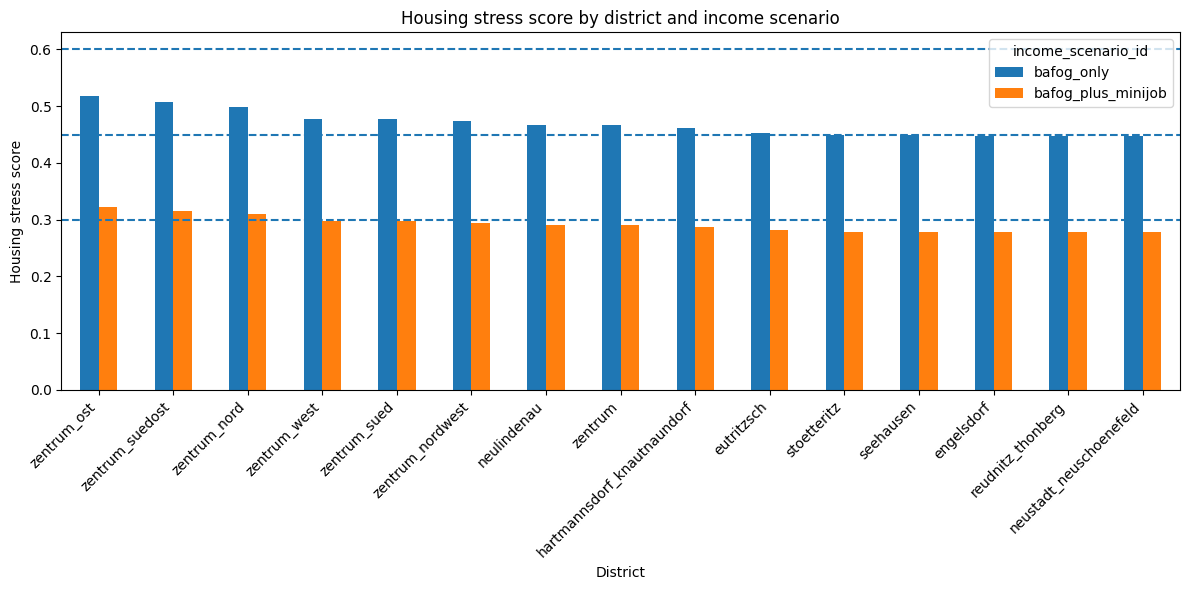

In [34]:
plot_data = affordability.pivot(
    index="district_id",
    columns="income_scenario_id",
    values="housing_stress_score",
)

plot_data = plot_data.sort_values("bafog_only", ascending=False).head(15)

ax = plot_data.plot(kind="bar", figsize=(12, 6))

ax.axhline(0.30, linestyle="--")
ax.axhline(0.45, linestyle="--")
ax.axhline(0.60, linestyle="--")

ax.set_title("Housing stress score by district and income scenario")
ax.set_ylabel("Housing stress score")
ax.set_xlabel("District")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()